In [2]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date,timedelta
today=date.today()

d1=today.strftime("%Y-%m-%d")
end_date=d1
d2=date.today()-timedelta(days=5000)
d2=d2.strftime("%Y-%m-%d")
start_date=d2

# data=yf.download('NFLX',start=start_date,end=end_date,progress=False)
# data["Date"]=data.index
# data=data[["Date","Open","High","Low","Close","Adj Close","Volume"]]
# data.reset_index(drop=True,inplace=True)

data = yf.download('NFLX', start=start_date, end=end_date, progress=False)

data["Date"] = data.index
# Simply remove "Adj Close" from the selection
data = data[["Date", "Open", "High", "Low", "Close", "Volume"]]
data.reset_index(drop=True, inplace=True)
print(data.tail())

Price        Date       Open       High        Low      Close     Volume
Ticker                  NFLX       NFLX       NFLX       NFLX       NFLX
3434   2026-01-16  88.339996  88.510002  87.779999  88.000000   48130500
3435   2026-01-20  88.970001  89.900002  87.019997  87.260002  109729700
3436   2026-01-21  82.519997  86.000000  81.930000  85.360001  127940700
3437   2026-01-22  85.019997  85.099998  82.980003  83.540001   69113300
3438   2026-01-23  83.430000  86.300003  83.279999  86.120003   64420500


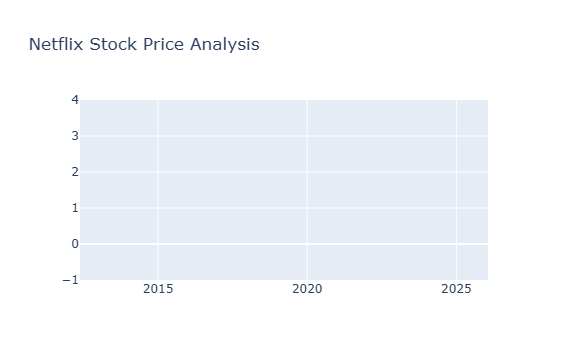

In [8]:
# import plotly.graph_objects as go 
# figure=go.Figure(data=[go.Candlestick(x=data["Date"],
#                                       open=data["Open"],
#                                       high=data["High"],
#                                       low=data["Low"],
#                                       close=data["Close"])])
# # figure.update_layout(title="Netflix Stock Price Analysis",xaxis_rangeslider=False)
# figure.update_layout(title="Netflix Stock Price Analysis", xaxis_rangeslider_visible=False)

# figure.show()

import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x=data["Date"],
                                        open=data["Open"], 
                                        high=data["High"],
                                        low=data["Low"], 
                                        close=data["Close"])])
figure.update_layout(title = "Netflix Stock Price Analysis", 
                     xaxis_rangeslider_visible=False)
figure.show()

In [17]:
correlation = data.corr(numeric_only=True) # numeric_only avoids errors with 'Date' columns
# Flatten the MultiIndex columns
data.columns = data.columns.get_level_values(0)

# Now your existing code should work perfectly:
correlation = data.corr(numeric_only=True)
print(correlation["Close"].sort_values(ascending=False))
# print(correlation["Close"].sort_values(by="Close", ascending=False))

Price
Close     1.000000
Low       0.999852
High      0.999839
Open      0.999631
Volume   -0.454778
Name: Close, dtype: float64


In [18]:
x = data[["Open", "High", "Low", "Volume"]]
y = data["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, 
                                                test_size=0.2, 
                                                random_state=42)

In [19]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (xtrain.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.summary()

C:\Users\chauh\miniconda3\envs\codexenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 4, 128)              │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(xtrain, ytrain, batch_size=1, epochs=30)

Epoch 1/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 61.8434 
Epoch 2/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 5.8533
Epoch 3/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.5342
Epoch 4/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 4.6264
Epoch 5/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.7711
Epoch 6/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.0216
Epoch 7/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.0781
Epoch 8/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 3.2585
Epoch 9/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.9940
Epoch 10/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2.2596
Epoch 11/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.4696
Epoch 12/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.6366
Epoch 13/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.0110
Epoch 14/30
2751/2751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2.5175
Epoch 15/30
2751/2751 ━━━━━

In [21]:
import numpy as np
#features = [Open, High, Low, Adj Close, Volume]
features = np.array([[401.970001, 427.700012, 398.200012, 20047500]])
model.predict(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


array([[115.454796]], dtype=float32)